# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [4]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.plot import Plot

# frank1d
from frank.utilities import UVDataBinner

## Functions

In [5]:
def calculate_resolution( clean_beam, intrinsic_resolution):
    bmaj_as = clean_beam['bmaj']
    bmin_as = clean_beam['bmin']
    final_bmaj_as = np.sqrt(bmaj_as**2 - intrinsic_resolution**2)
    final_bmin_as = np.sqrt(bmin_as**2 - intrinsic_resolution**2)
    print(f"-> Final beam to convolve with: {final_bmaj_as} x {final_bmin_as} arcsec")
    final_resolution = {'bmaj': final_bmaj_as, 'bmin': final_bmin_as, 'beam_pa': clean_beam['beam_pa']}
    return final_resolution

In [6]:
def edges(x):
    mids = (x[1:] + x[:-1]) / 2.0
    first = x[0]  - (x[1] - x[0]) / 2.0
    last  = x[-1] + (x[-1] - x[-2]) / 2.0
    return np.r_[first, mids, last]


In [7]:
def get_profile( x1, x2, f, bins, weighted = False, weights = None, fit_1d = False):
    from scipy.stats import binned_statistic
    
    if not fit_1d:
        r = np.hypot(x1, x2)
        r = r.ravel(order = 'C')
        f = f.ravel(order = 'C')
    else:
        r = x1

    if weighted:
        if weights is None:
            raise ValueError("Add weights.")
        F_W_binned, bin_edges, _ = binned_statistic(r, f*weights, 'sum', bins = bins)
        Weights_binned, bin_edges, _ = binned_statistic(r, weights, 'sum', bins = bins)

        f_1d = np.nan_to_num(F_W_binned, nan=0)
        f_1d = f_1d/Weights_binned
    else:
        f_1d, bin_edges, _ = binned_statistic(r, f, 'mean', bins = bins)
    
    r_1d = (bin_edges[:-1] + bin_edges[1:]) / 2
        
    return r_1d, f_1d

# Data

In [8]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [9]:
data = Elias27

# UVtable
dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [10]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [11]:
N = 300

In [12]:
geom_f2d = Geometry(inc, pa, dra, ddec)

In [13]:
frank2d = Frank2D(N, rout, geom_f2d)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [15]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [16]:
best = {'m': -3.2974308124121103, 'c': 316116053366190.75, 'l': 44039.70624900817}

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.07  min |  4.14 seconds
--> time = 0.07  min |  4.34 seconds
Solving linear system...
         * rtol: 1e-07
         * final tolerance: 5.684907757598305
Final tolerance :  5.684907757598305
.... iteration:  0
                        -> actual tol:  56849077.575983055 vs  5.684907757598305
.... iteration:  1
                        -> actual tol:  21714280.318749465 vs  5.684907757598305
.... iteration:  2
                        -> actual tol:  4222174.215376105 vs  5.684907757598305
.... iteration:  3
                        -> actual tol:  3512531.687365373 vs  5.684907757598305
.... iteration:  4
                        -> actual tol:  3531610.308409273 vs  5.684907757598305
.... iteration:  5
                        -> actual tol:  3071092.7635244587 vs  5.684907757598305
.... iteration:  6
                        -> actual tol:  2861188.405754701 vs  5.684907757598305
.... iteration:  7
          

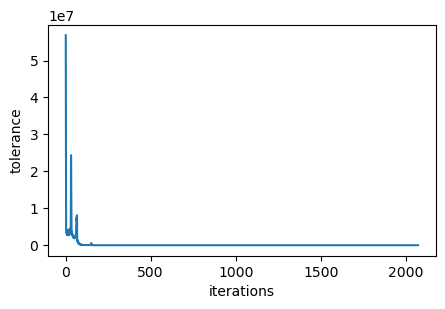

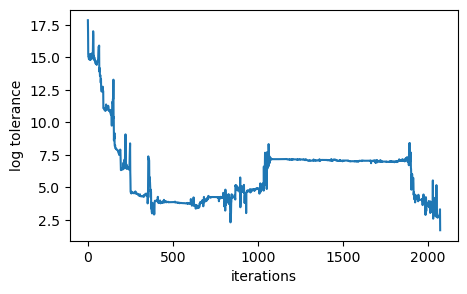

--> time = 2.69  min |  161.14 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 2.88 minutes.


In [17]:
start_time = time.time()

frank2d.fit(kernel_params = best, rtol = 1e-7 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes.")

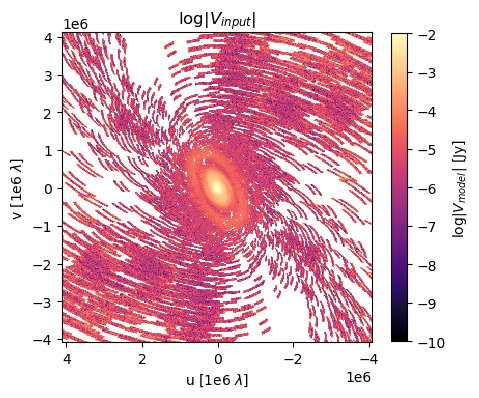

In [20]:
Plot(frank2d, geom_f2d).visibility(kind='input', fig_size = 5, title = r'log|$V_{input}$|')

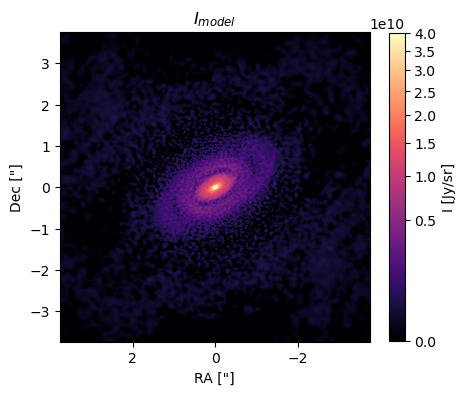

In [21]:
Plot(frank2d, geom_f2d).intensity(fig_size = 5, title = r'$I_{model}$')

## CLEAN MODEL

In [22]:

dir = "/Users/mariajmelladot/Desktop/Frank2D/data/CLEAN_models/"
disk_name = data['disk_name']
data_file = dir +"CLEAN_model_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u_c, v_c, Re_c, Im_c, Weights_c = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis_c = Re_c + Im_c*1j

In [23]:
# clean model
u_model_c = u_c
v_model_c = v_c
vis_model_c = Vis_c
weights_model_c = Weights_c

# Vis space


## 1D profile
We use the full uvtable to make the profile.

In [36]:
    f2d = frank2d
    geom = geom_f2d

In [37]:
u_input = uvtable['u']
v_input = uvtable['v']
vis_input = uvtable['vis']
weights_input = uvtable['weights']

u_model_1d_f2d = f2d.u
v_model_1d_f2d = f2d.v

In [44]:
# f2d model
u_model_f2d = f2d.u_grid
v_model_f2d = f2d.v_grid
vis_model_f2d = f2d.visibility_model

In [38]:
# phase_shift
# is necessary to be done in the East of North convention.
vis_input = geom.apply_phase_shift(-u_input, -v_input, vis_input)
vis_model_f2d = geom.apply_phase_shift(-u_model_f2d, -v_model_f2d, vis_model_f2d)
vis_model_c = geom.apply_phase_shift(-u_model_c, -v_model_c, vis_model_c)
    
# deproject
u_model_f2d, v_model_f2d, _ = geom.deproject(u_model_f2d, v_model_f2d)
u_model_1d_f2d, v_model_1d_f2d, _ = geom.deproject(u_model_1d_f2d, v_model_1d_f2d)
u_input, v_input, _ = geom.deproject(u_input, v_input)
u_model_c, v_model_c, _ = geom.deproject(u_model_c, v_model_c)


# collocation points for the plot.
q = np.unique(np.hypot(u_model_1d_f2d, v_model_1d_f2d))
q = np.sort(q)[1:]
bins = 300
q = np.geomspace(q[0], q[-1], bins)
edges_ = edges(q)

# ----------------
baselines = np.hypot(u_input, v_input)         
grid = np.logspace(np.log10(min(baselines.min(), baselines[0])),
                            np.log10(max(baselines.max(), baselines[-1])),
                            10**4)

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']
bin_widths = [1e3, 1e5]

binned_vis0 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[0])
binned_vis1 = UVDataBinner(baselines, vis_input, weights_input, bin_widths[1])


# ----------------
                                    

In [ ]:
q_model_1d_f2d, vis_model_1d_f2d = get_profile(u_model_f2d, v_model_f2d, vis_model_f2d,
                                            bins = edges_,
                                            weighted = False, weights = frank2d.gridded_data['weights'])

#vis_model_1d_f2d = np.nan_to_num(vis_model_1d_f2d, nan=0)


In [ ]:

q_model_1d_c, vis_model_1d_c = get_profile(u_model_c, v_model_c, vis_model_c,
                                                bins = edges_,
                                                weighted = False, weights = weights_model_c)

#vis_model_1d_c = np.nan_to_num(vis_model_1d_c, nan=0)

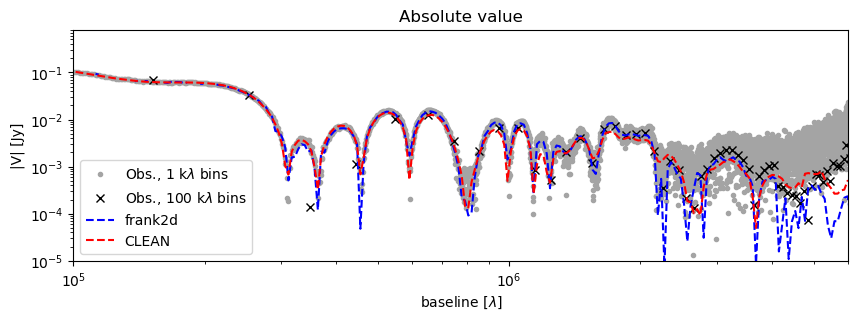

In [ ]:
plt.figure(figsize=(10,3))
# Raw visibilities ---------------------------------------------------------

plt.plot(binned_vis0.uv, np.abs(binned_vis0.V), c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, np.abs(binned_vis1.V), c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank2D -------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_f2d), color = 'blue', ls ='--', label = r'frank2d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, np.abs(vis_model_1d_c), color = 'red', ls ='--', label = r'CLEAN')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 0)
plt.xlim(1e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title('Absolute value')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

In [ ]:
residual = vis_model_1d_f2d-vis_model_1d_c

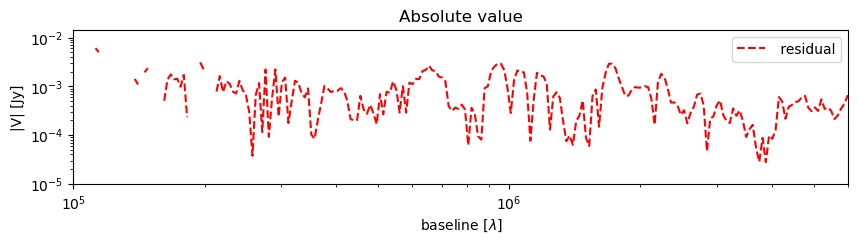

In [ ]:
plt.figure(figsize=(10,2))
plt.plot(q, np.abs(residual), color = 'red', ls ='--', label = r' residual')
plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5, 0)
plt.xlim(1e5, 6e6)
plt.ylabel('|V| [Jy]', size = 10)
plt.title('Absolute value')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

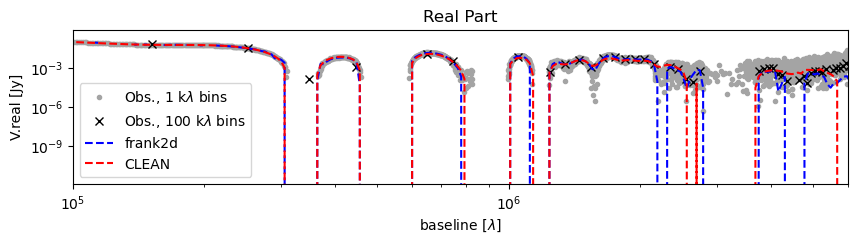

In [ ]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------
plt.plot(binned_vis0.uv, binned_vis0.V.real, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.real, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.real, color = 'blue', ls ='--', label = r'frank2d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.real, color = 'red', ls ='--', label = r'CLEAN')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(-0.025, 0.11)
plt.xlim(1e5, 6e6)
plt.ylabel('V.real [Jy]', size = 10)
plt.title('Real Part')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

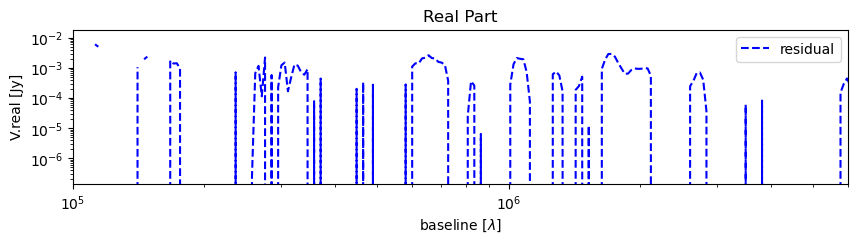

In [ ]:
plt.figure(figsize=(10,2))
plt.plot(q, residual.real, color = 'blue', ls ='--', label = r'residual')
plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(-0.025, 0.11)
plt.xlim(1e5, 6e6)
plt.ylabel('V.real [Jy]', size = 10)
plt.title('Real Part')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

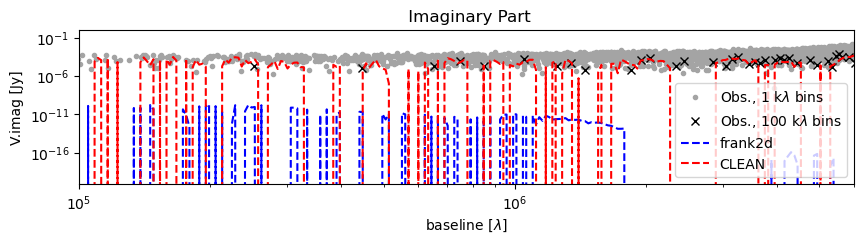

In [ ]:
plt.figure(figsize=(10,2))
# Raw visibilities ---------------------------------------------------------
plt.plot(binned_vis0.uv, binned_vis0.V.imag, c=cs[0],
                marker=ms[0], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))

plt.plot(binned_vis1.uv, binned_vis1.V.imag, c=cs[1],
                marker=ms[1], ls='None', 
                label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

# frank2D -------------------------------------------------------------------
plt.plot(q, vis_model_1d_f2d.imag, color = 'blue', ls ='--', label = r'frank2d')

# CLEAN ---------------------------------------------------------------------
plt.plot(q, vis_model_1d_c.imag, color = 'red', ls ='--', label = r'CLEAN')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-5, 0)
plt.xlim(1e5, 6e6)
plt.ylabel('V.imag [Jy]', size = 10)
plt.title(' Imaginary Part')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

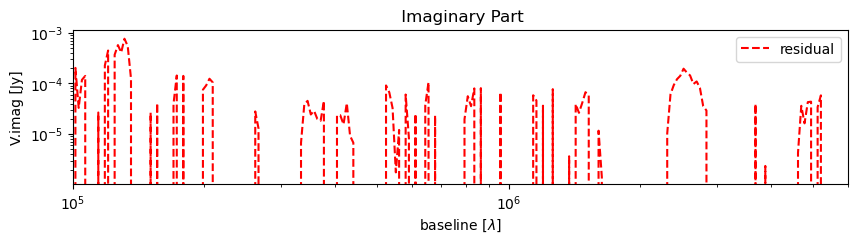

In [ ]:
plt.figure(figsize=(10,2))
plt.plot(q, residual.imag, color = 'red', ls ='--', label = r'residual')

plt.xlabel(r'baseline [$\lambda$]')
plt.xscale('log')
plt.yscale('log')
#plt.ylim(1e-5, 0)
plt.xlim(1e5, 6e6)
plt.ylabel('V.imag [Jy]', size = 10)
plt.title(' Imaginary Part')
plt.legend(fontsize= 10, loc = 'best')
plt.show()

## 2D map

In [24]:
N = 300

In [25]:
frank2d1 = Frank2D(N, rout, geom_f2d)

#### Gridding

In [26]:
uvtable_clean = {'u': u_model_c, 'v': v_model_c, 'vis': vis_model_c, 'weights': weights_model_c}

In [27]:
len(u_model_c)

36803272

In [28]:
frank2d1.process_vis(uvtable_clean)

Setting gridded data...


In [29]:
u_model_c_grid, v_model_c_grid = frank2d1.gridded_data['u'], frank2d1.gridded_data['v']
vis_model_c_grid = frank2d1.gridded_data['vis']
weights_model_c_grid = frank2d1.gridded_data['weights']

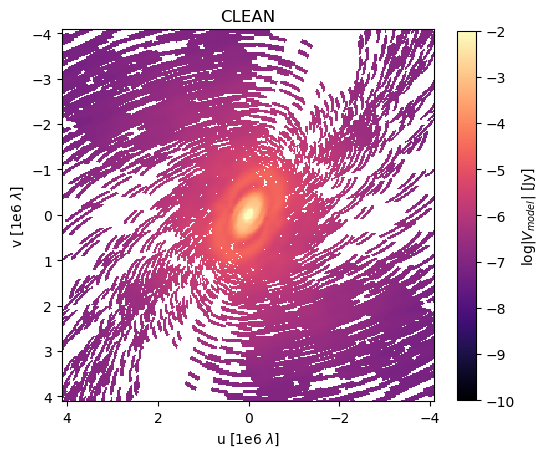

In [30]:
u_c, v_c = -u_model_c_grid.reshape(N,N), -v_model_c_grid.reshape(N,N)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_c/1e6, v_c/1e6,
            np.log(np.abs(vis_model_c_grid.reshape(N,N))),
            cmap="magma",
            vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("CLEAN")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_c.max()/1e6, u_c.min()/1e6)
plt.ylim(v_c.max()/1e6, v_c.min()/1e6)
plt.gca().set_aspect(1)
plt.show()

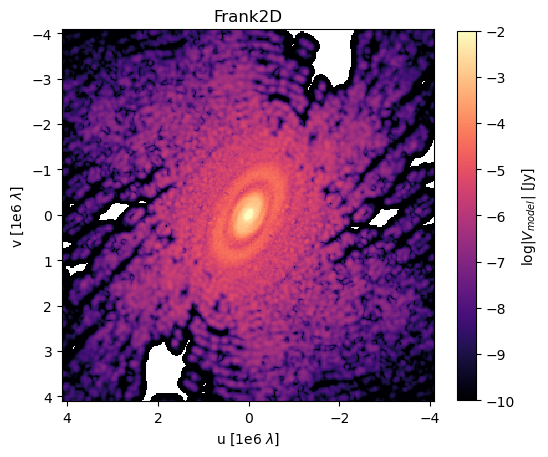

In [31]:
u_c, v_c = -frank2d.u_grid.reshape(N,N), -frank2d.v_grid.reshape(N,N)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_c/1e6, v_c/1e6,
                np.log(np.abs(frank2d.visibility_model.reshape(N,N))),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("Frank2D")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_c.max()/1e6, u_c.min()/1e6)
plt.ylim(v_c.max()/1e6, v_c.min()/1e6)
plt.gca().set_aspect(1)
plt.show()

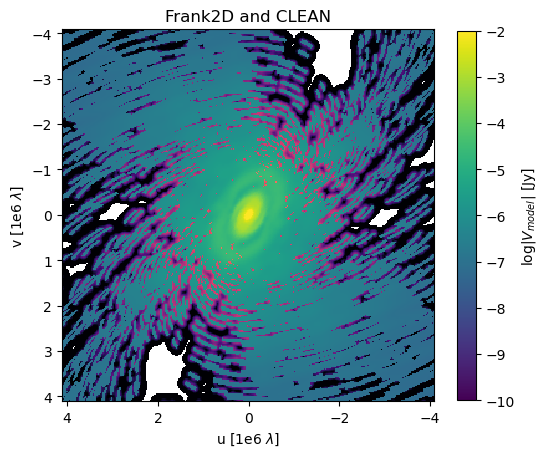

In [32]:
u_c, v_c = -frank2d.u_grid.reshape(N,N), -frank2d.v_grid.reshape(N,N)

plt.figure(figsize = (6, 6))
plt.pcolormesh( u_c/1e6, v_c/1e6,
                np.log(np.abs(frank2d.visibility_model.reshape(N,N))),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.pcolormesh( u_c/1e6, v_c/1e6,
                np.log(np.abs(vis_model_c_grid.reshape(N,N))),
                cmap="viridis",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("Frank2D and CLEAN")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_c.max()/1e6, u_c.min()/1e6)
plt.ylim(v_c.max()/1e6, v_c.min()/1e6)
plt.gca().set_aspect(1)
plt.show()

In [45]:
frank2d4 = Frank2D(N, rout, geom_f2d)

In [46]:
uvtable_f2d_model = {'u': u_model_f2d.ravel(order = 'C'), 'v': v_model_f2d.ravel(order = 'C'), 
                    'vis': vis_model_f2d.ravel(order = 'C'), 
                    'weights': frank2d.gridded_data['weights']}

In [47]:
frank2d4.process_vis(uvtable_f2d_model)

Setting gridded data...


In [48]:
u_f2d_model_gridded = frank2d4.gridded_data['u']
v_f2d_model_gridded = frank2d4.gridded_data['v']
vis_f2d_model_gridded = frank2d4.gridded_data['vis']
weights_f2d_model_gridded = frank2d4.gridded_data['weights']

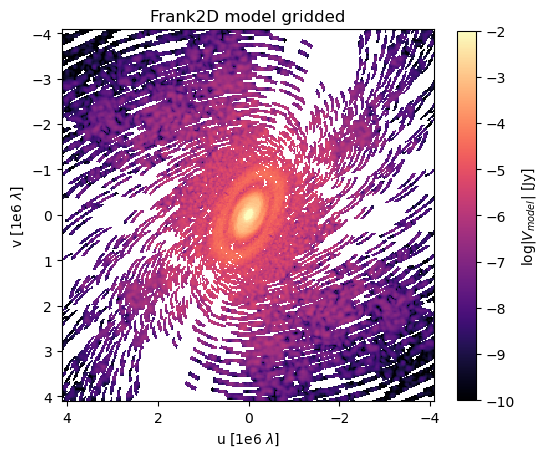

In [49]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_c/1e6, v_c/1e6,
                np.log(np.abs(vis_f2d_model_gridded.reshape(N,N) )),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("Frank2D model gridded")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_c.max()/1e6, u_c.min()/1e6)
plt.ylim(v_c.max()/1e6, v_c.min()/1e6)
plt.gca().set_aspect(1)
plt.show()

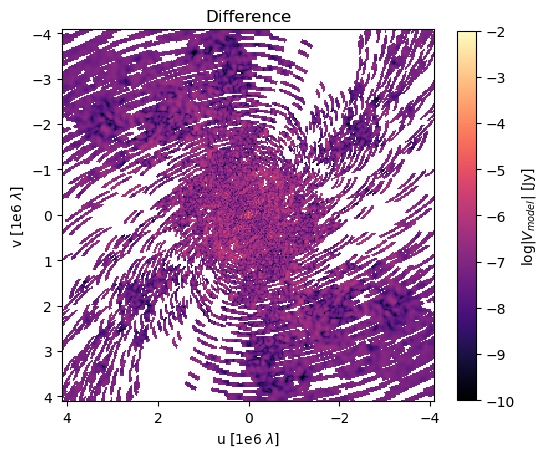

In [50]:
plt.figure(figsize = (6, 6))
plt.pcolormesh( u_c/1e6, v_c/1e6,
                np.log(np.abs(vis_model_c_grid.reshape(N,N) - vis_f2d_model_gridded.reshape(N,N) )),
                cmap="magma",
                vmin=-10, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title("Difference")
cmap = plt.colorbar(shrink=0.8)
cmap.set_label(r'log|$V_{model}$| [Jy]', size=10)
plt.xlim(u_c.max()/1e6, u_c.min()/1e6)
plt.ylim(v_c.max()/1e6, v_c.min()/1e6)
plt.gca().set_aspect(1)
plt.show()

# Real space

## 2D image
1) Interpolate to a 2D grid the fft of complete uvtable. or
2) Use tclean param to convert into a grid the final image and use that image.

### Frank2D first: set imsize and cell of F2D image

In [51]:
imsize = 3000

In [52]:
frank2d2 = Frank2D(imsize, rout, geom_f2d)

Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.17  min |  10.30 seconds
--> time = 0.18  min |  10.82 seconds
Solving linear system...
         * rtol: 1e-07
         * final tolerance: 5.685109889292831
Final tolerance :  5.685109889292831
.... iteration:  0
                        -> actual tol:  56851098.89292831 vs  5.685109889292831
.... iteration:  1
                        -> actual tol:  21720076.39210242 vs  5.685109889292831
.... iteration:  2
                        -> actual tol:  4234484.742107189 vs  5.685109889292831
.... iteration:  3
                        -> actual tol:  3514730.47571064 vs  5.685109889292831
.... iteration:  4
                        -> actual tol:  3535680.9705096763 vs  5.685109889292831
.... iteration:  5
                        -> actual tol:  3074361.2005030555 vs  5.685109889292831
.... iteration:  6
                        -> actual tol:  2881693.166793296 vs  5.685109889292831
.... 

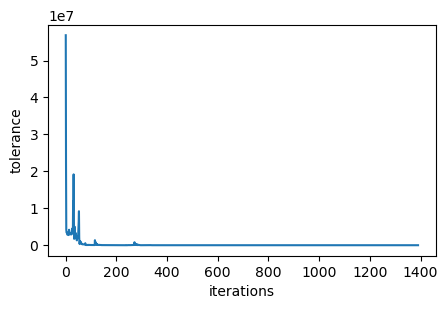

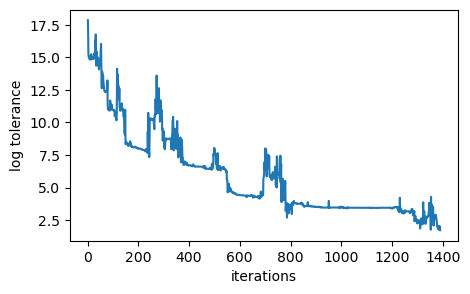

--> time = 8.79  min |  527.23 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...


In [53]:
frank2d2.fit(data = uvtable, kernel_params = best, rtol = 1e-7 )

In [54]:
Plot_ = Plot(frank2d2, geom_f2d)

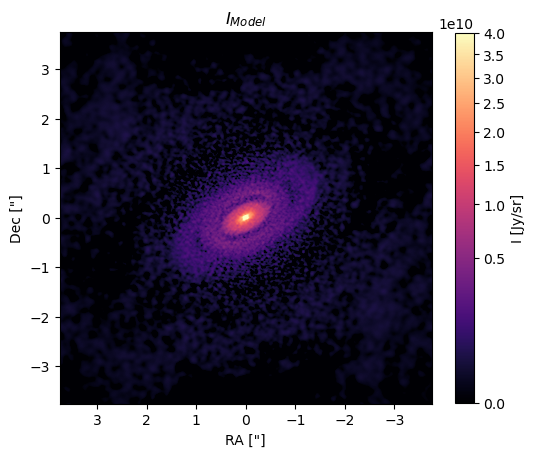

In [55]:
Plot_.intensity()

In [56]:
cell = (frank2d2.x[1]-frank2d2.x[0]) * rad_to_arcsec
cell

0.0025066666666664038


0.0025066666666664038

### Open fits file
Of image regridded in CASA with imregrid, the same image from where we got the CLEAN model.

In [29]:
from astropy.io import fits

dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
#disk = disk_name + '_continuum.fits'
disk = disk_name + '_model.fits'

fits_name = dir + disk
hdul = fits.open(fits_name)

In [67]:
import matplotlib.colors as colors

### Do an image

In [30]:
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS

In [31]:
hdr = hdul[0].header
data = hdul[0].data 

In [32]:
# beam
bmaj = hdr.get('BMAJ') # degrees
bmaj_arsec = bmaj * 3600 # arcseconds
bmin = hdr.get('BMIN')
bmin_arsec = bmin * 3600 # arcseconds
bpa = hdr.get('BPA')

In [33]:
w = WCS(hdr)

In [34]:
data_squeezed = np.squeeze(data)   # (3000,3000) si los ejes 1 desaparecen
print("shape original:", data.shape, "-> squeezed:", data_squeezed.shape)

shape original: (1, 1, 3000, 3000) -> squeezed: (3000, 3000)


In [35]:
data = data_squeezed

In [36]:
if data.ndim == 3:
    # asumo (nz, ny, nx)
    nz, ny, nx = data.shape
    if channel_index is None:
        # elige el canal central por defecto
        ci = nz // 2
    else:
        ci = int(channel_index)
    img = data[ci, :, :].copy()
    # build a WCS for the 2D plane (drop the spectral axis)
    w2 = w.celestial  # WCS restringido a ejes celestes (RA/Dec)
else:
    ny, nx = data.shape
    img = data.copy()
    w2 = w.celestial

In [37]:
# pixel coordinates
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# wcs expects pixel coords in 1-based -> use wcs_pix2world with origin=0
ra_deg, dec_deg = w2.wcs_pix2world(xx, yy, 0)  # devuelve en grados

# reference coordinate (CRVAL)
crval_ra = w2.wcs.crval[0]
crval_dec = w2.wcs.crval[1]
refcoord = SkyCoord(crval_ra*u.deg, crval_dec*u.deg)

# compute offsets in arcsec from reference coordinate
coords = SkyCoord(ra_deg*u.deg, dec_deg*u.deg)
lon_off, lat_off = coords.spherical_offsets_to(refcoord)
# convertir a arcsec, y poner el eje x como RA offset (positivo hacia el Este)
ra_off_arcsec = -lon_off.to(u.arcsec).value
dec_off_arcsec = lat_off.to(u.arcsec).value

# extent of the image in arcsec (for imshow)
xmin = ra_off_arcsec.min()
xmax = ra_off_arcsec.max()
ymin = dec_off_arcsec.min()
ymax = dec_off_arcsec.max()

# we need to flip the y axis to match the imshow convention
img = np.flipud(img)



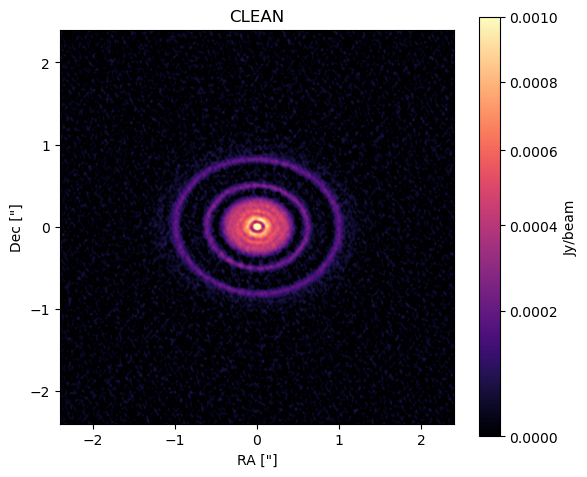

In [91]:
plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.75, vmin=0, vmax=0.0010)
ax = plt.gca()
im = ax.imshow(
    img,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title('CLEAN')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(hdr.get('BUNIT', 'Intensity'))
ax.grid(False)
plt.tight_layout()
plt.show()

In [39]:
# arcsecs per pixel
ra_off_arcsec[0][1] -ra_off_arcsec[0][0]

-0.0016000046066801943

### Convolve f2d

In [40]:
I_f2d = frank2d2.intensity_model

In [41]:
I_f2d.shape 

(3000, 3000)

**Jy/sr $\implies$ Jy/beam**

In [42]:
FHWM_maj = bmaj_arsec / rad_to_arcsec
FHWM_min = bmin_arsec / rad_to_arcsec
omega = ( np.pi / 4 * np.log(2) ) * FHWM_maj * FHWM_min
I_f2d_Jybeam = I_f2d * omega

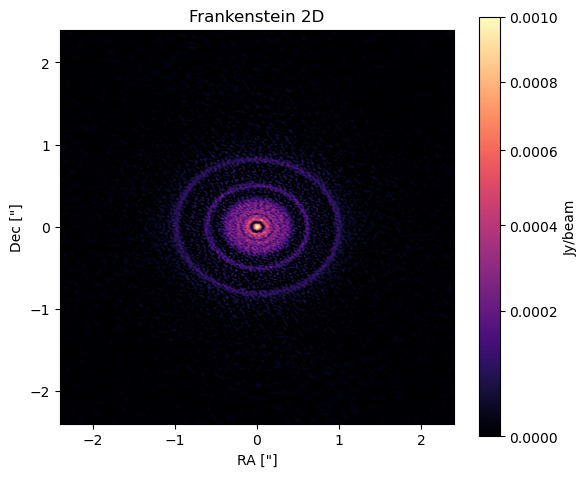

In [92]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell


plt.figure(figsize=(6,5))
norm = colors.PowerNorm(gamma=0.75, vmin=0, vmax=0.0010)
ax = plt.gca()
im = ax.imshow(
    I_f2d_Jybeam,
    extent=[xmin, xmax, ymin, ymax],
    aspect='equal',
    cmap='magma',
    norm=norm,
)
ax.set_xlabel('RA ["]')
ax.set_ylabel('Dec ["]')
ax.set_title('CLEAN')
cbar = plt.colorbar(im, ax=ax)
plt.title('Frankenstein 2D')
cbar.set_label('Jy/beam')
ax.grid(False)
plt.tight_layout()
plt.show()

**Convolution**

In [44]:
from radio_beam import Beam
from astropy.convolution import convolve_fft, Gaussian2DKernel

In [45]:
FWHM_frank2d = 0.022905863089907247

In [46]:
hdr['BMAJ']*u.deg

<Quantity 1.06156369e-05 deg>

In [47]:
# defining beams
beam_orig =  Beam(major=FWHM_frank2d*u.arcsec, minor=FWHM_frank2d*u.arcsec, pa=0*u.deg)
beam_target = Beam(major=bmaj_arsec*u.arcsec, minor=bmin_arsec*u.arcsec, pa=hdr['BPA']*u.deg)

In [48]:
# calculating convolution beam
conv_beam = beam_target.deconvolve(beam_orig)

In [49]:
# creating kernel in pixels
pixscale = abs(hdr['CDELT2'])*u.deg
sigma_conv_pix = (conv_beam.major / (2.355 * pixscale)).decompose().value
kernel = Gaussian2DKernel(sigma_conv_pix)

In [50]:
# convolve
I_f2d_Jybeam_conv = convolve_fft(I_f2d_Jybeam, kernel, boundary='wrap')

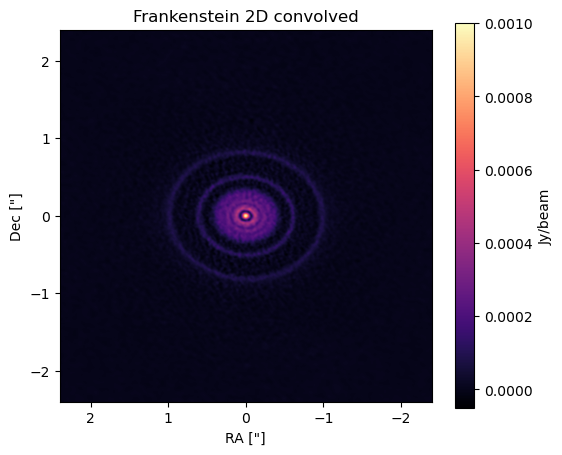

In [79]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell
plt.figure(figsize=(6,5))
plt.imshow(I_f2d_Jybeam_conv, aspect='equal',
          extent=[xmax, xmin, ymin, ymax], cmap="magma", 
          vmax =0.0010)
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.title('Frankenstein 2D convolved')
cbar = plt.colorbar(norm = norm)
cbar.set_label('Jy/beam')

#### Difference

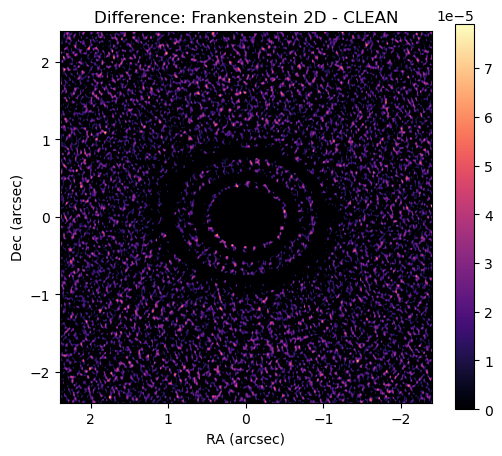

In [83]:
xmin = - (imsize/2) * cell
xmax = (imsize/2) * cell
ymin = - (imsize/2) * cell
ymax = (imsize/2) * cell
plt.figure(figsize=(6,5))
plt.imshow(I_f2d_Jybeam_conv - img, aspect='equal', vmin=0, extent=[xmax, xmin, ymin, ymax], 
            cmap = 'magma')
plt.xlabel('RA (arcsec)')
plt.ylabel('Dec (arcsec)')
plt.title('Difference: Frankenstein 2D - CLEAN')
plt.colorbar()

## 1D Profile

In [53]:
f2d = frank2d
geom = geom_f2d
inc, pa, dra, ddec = geom.inc, geom.pa, geom.dra, geom.ddec

FWHM_frank2d = 0.022905863089907247

In [54]:
from astropy.io import fits

dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
#disk = disk_name + '_continuum.fits'
disk = disk_name + '_model.fits'

fits_name = dir + disk
hdul = fits.open(fits_name)


In [55]:
from gofish import imagecube
cube_1mm = imagecube(fits_name)
x_clean, y_clean, dy_clean = cube_1mm.radial_profile(inc= inc, PA=pa, x0=dra, y0=ddec)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


In [56]:
fits_image = fits.open(fits_name)
header = fits_image[0].header
bmaj_deg = float(header["BMAJ"])
bmin_deg = float(header["BMIN"])
bmaj_as = bmaj_deg * 3600.0
bmin_as = bmin_deg * 3600.0
bpa_deg = header['BPA']

clean_beam = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
clean_area = clean_beam['bmaj']*clean_beam['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2
area = clean_area
print(f"Clean beam: {bmaj_as} x {bmin_as} arcsec")

beam_for_f2d = calculate_resolution(clean_beam, FWHM_frank2d)

Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
-> Final beam to convolve with: 0.03059095415189107 x 0.028063616248335515 arcsec


In [57]:


# f2d model
u_model = f2d.u_grid
v_model = f2d.v_grid
vis_model = f2d.visibility_model

u_model_1d = f2d.u
v_model_1d = f2d.v

x_model = f2d.x_grid * rad_to_arcsec
y_model = f2d.y_grid * rad_to_arcsec

x_model_1d = f2d.x * rad_to_arcsec
y_model_1d = f2d.y * rad_to_arcsec

        
# phase shift
vis = geom.apply_phase_shift(-u_model, -v_model, vis_model) # the East of North convention.
I = f2d.transform(vis).real

# deproject
x_model, y_model = geom.deproject_xy(x_model, y_model)
x_model_1d_d, y_model_1d_d = geom.deproject_xy(x_model_1d, y_model_1d)

# collocation points for the plot.
r = np.unique(np.hypot(x_model_1d_d, y_model_1d_d))
bins = 800
r = np.linspace(r.min(), r.max(), bins)
edges_ = edges(r)


r_model_1d, I_model_1d = get_profile(x_model, y_model, I, bins = edges_)
I_model_1d = np.nan_to_num(I_model_1d, nan=0)

In [58]:
from frank.utilities import convolve_profile
I_model_1d_convolved = convolve_profile(r_model_1d, I_model_1d, inc, pa, beam_for_f2d)
I_model_1d_convolved *= area # Jy/beam

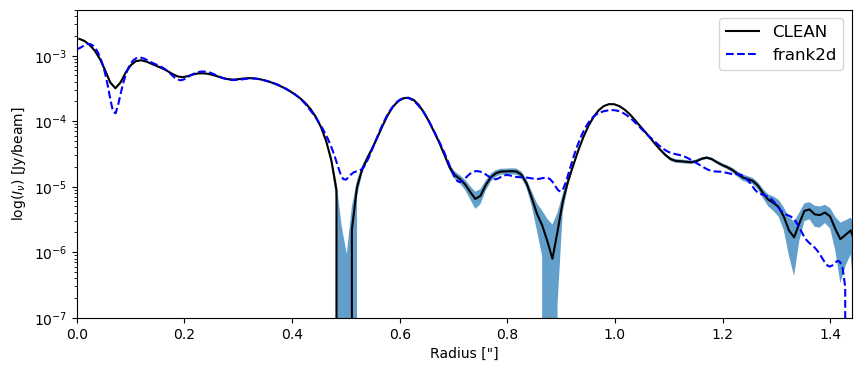

In [59]:
plt.figure(figsize=(10,4))
#  CLEAN --------------------------------------------------------------------
plt.plot(x_clean, y_clean, "black", label = "CLEAN")
plt.fill_between(x_clean, y_clean-dy_clean, y_clean+dy_clean, alpha=0.7)
# frank2D -------------------------------------------------------------------
plt.plot(r_model_1d, I_model_1d_convolved, color = 'blue',ls ='--', label = r'frank2d')

plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('Radius ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.xlim(0, rout*0.6)
plt.ylim(1e-7, 0.5e-2)
plt.show()